<a href="https://colab.research.google.com/github/sorana01/Student-Performance-Analysis/blob/main/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Student Performance Analysis & Prediction

Acest notebook rezolvă următoarele cerințe:

1. Analiza EDA pentru identificarea factorilor ce influențează performanța studenților.
2. Construirea unui model ML pentru estimarea notei la examen.
3. Generarea unui student fictiv și estimarea notei sale.
4. Crearea și testarea unor sugestii pentru îmbunătățirea notei folosind modelul.

Dataset utilizat: `StudentPerformanceFactors.csv`


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data_path = r"/content/sample_data/StudentPerformanceFactors.csv"
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



## 1. Exploratory Data Analysis (EDA)

Analizăm:
- distribuția notelor,
- corelațiile numerice,
- impactul principalilor factori asupra performanței.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

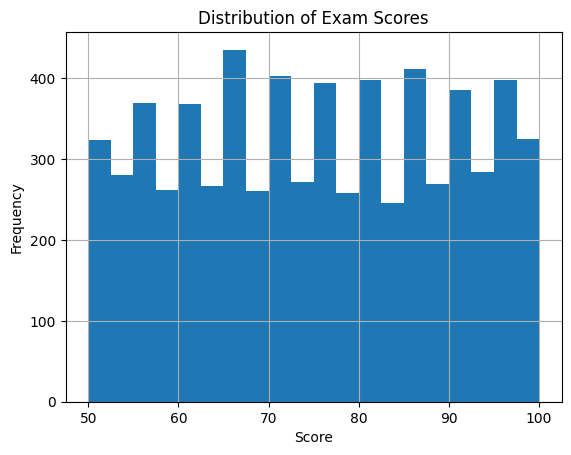

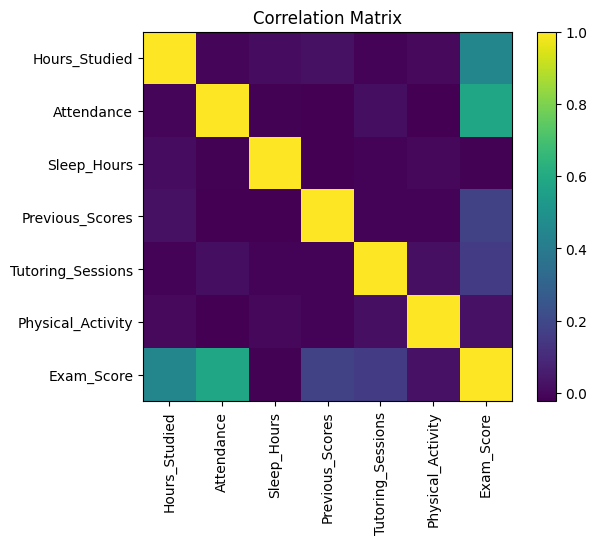

In [ ]:

# Basic info
df.info()

# Statistics
df.describe()

# Distribution of exam score (assuming column name contains 'Score' or similar)
target_col = None
for col in df.columns:
    if "score" in col.lower() or "exam" in col.lower():
        target_col = col
        break

print("Detected target column:", target_col)

plt.figure()
df[target_col].hist(bins=20)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# Correlation for numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure()
corr = numeric_df.corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()



## 2. Model ML pentru estimarea notei

Folosim:
- RandomForestRegressor
- preprocesare automată pentru variabile numerice și categorice


In [ ]:

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model = RandomForestRegressor(random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 12.74076567795336
R2: 0.21419592138543764



## 3. Student fictiv și estimarea notei

Generăm un student folosind valori medii sau frecvente din dataset.


In [ ]:

# Generate fictive student using mean/mode
student_data = {}

for col in X.columns:
    if col in numeric_features:
        student_data[col] = X[col].mean()
    else:
        student_data[col] = X[col].mode()[0]

student_df = pd.DataFrame([student_data])

predicted_score = pipeline.predict(student_df)[0]

print("Predicted exam score for fictive student:", predicted_score)
student_df


Predicted exam score for fictive student: 82.44


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,19.975329,79.977448,Medium,Medium,Yes,7.02906,Medium,Yes,1.493719,Low,Medium,Public,Positive,2.96761,No,High School,Near,Male,67.235659



## 4. Sugestii pentru îmbunătățirea notei

Simulăm îmbunătățiri pentru variabile relevante (ex: mai multe ore de studiu,
prezență mai bună etc.) și observăm efectul asupra notei estimate.


In [ ]:

def test_improvement(student, feature, delta):
    improved = student.copy()
    if feature in improved.columns:
        improved[feature] = improved[feature] + delta
        new_score = pipeline.predict(improved)[0]
        return new_score
    return None

baseline_score = pipeline.predict(student_df)[0]
print("Baseline score:", baseline_score)

suggestions = []

for feature in numeric_features:
    improved_score = test_improvement(student_df, feature, 1)
    if improved_score is not None and improved_score > baseline_score:
        suggestions.append((feature, improved_score))

print("\nSuggested improvements:")
for feat, score in suggestions[:5]:
    print(f"Increasing {feat} may raise score to approx {score:.2f}")


Baseline score: 82.44

Suggested improvements:
Increasing Exam_Score may raise score to approx 85.97
